# Exploratory Data Analysis (EDA)
This notebook provides an exploratory data analysis of the stellar classification dataset.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')
sns.set_palette('muted')

## Load Data

In [2]:
train = pd.read_csv('dataset/train.csv')
test = pd.read_csv('dataset/test.csv')
print(f"Train shape: {train.shape}")
print(f"Test shape: {test.shape}")
train.head()

Train shape: (577347, 12)
Test shape: (247435, 11)


,id,alpha,delta,u,g,r,i,z,redshift,spectral_type,galaxy_population,class
0,0,147.734256,16.959273,25.472123,21.895559,20.357926,19.257113,18.621057,0.408982,M,Red_Sequence,GALAXY
1,1,127.988677,32.346716,20.778509,19.087062,17.587208,17.226067,16.786433,0.157976,M,Red_Sequence,GALAXY
2,2,179.792648,35.344843,21.035203,21.079128,21.171840,20.582629,20.557366,2.823770,O/B,Blue_Cloud,QSO
3,3,225.818295,48.569421,23.305056,21.050736,19.017754,18.365658,17.914952,0.536099,M,Red_Sequence,GALAXY
4,4,141.836135,19.342852,21.703158,19.471680,18.234449,17.899447,17.616185,0.555761,M,Red_Sequence,GALAXY


## Basic Information

In [3]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 577347 entries, 0 to 577346
Data columns (total 12 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   id                 577347 non-null  int64  
 1   alpha              577347 non-null  float64
 2   delta              577347 non-null  float64
 3   u                  577347 non-null  float64
 4   g                  577347 non-null  float64
 5   r                  577347 non-null  float64
 6   i                  577347 non-null  float64
 7   z                  577347 non-null  float64
 8   redshift           577347 non-null  float64
 9   spectral_type      577347 non-null  object 
 10  galaxy_population  577347 non-null  object 
 11  class              577347 non-null  object 
dtypes: float64(8), int64(1), object(3)
memory usage: 52.9+ MB


In [4]:
print("Missing values in train:\n", train.isnull().sum())

Missing values in train:
 id                   0
alpha                0
delta                0
u                    0
g                    0
r                    0
i                    0
z                    0
redshift             0
spectral_type        0
galaxy_population    0
class                0
dtype: int64


## Target Variable Distribution

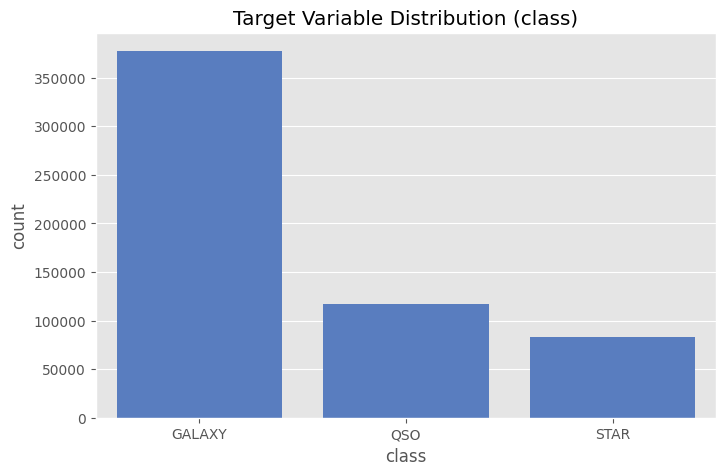

In [5]:
plt.figure(figsize=(8, 5))
sns.countplot(data=train, x='class')
plt.title('Target Variable Distribution (class)')
plt.show()

## Numerical Features Distribution

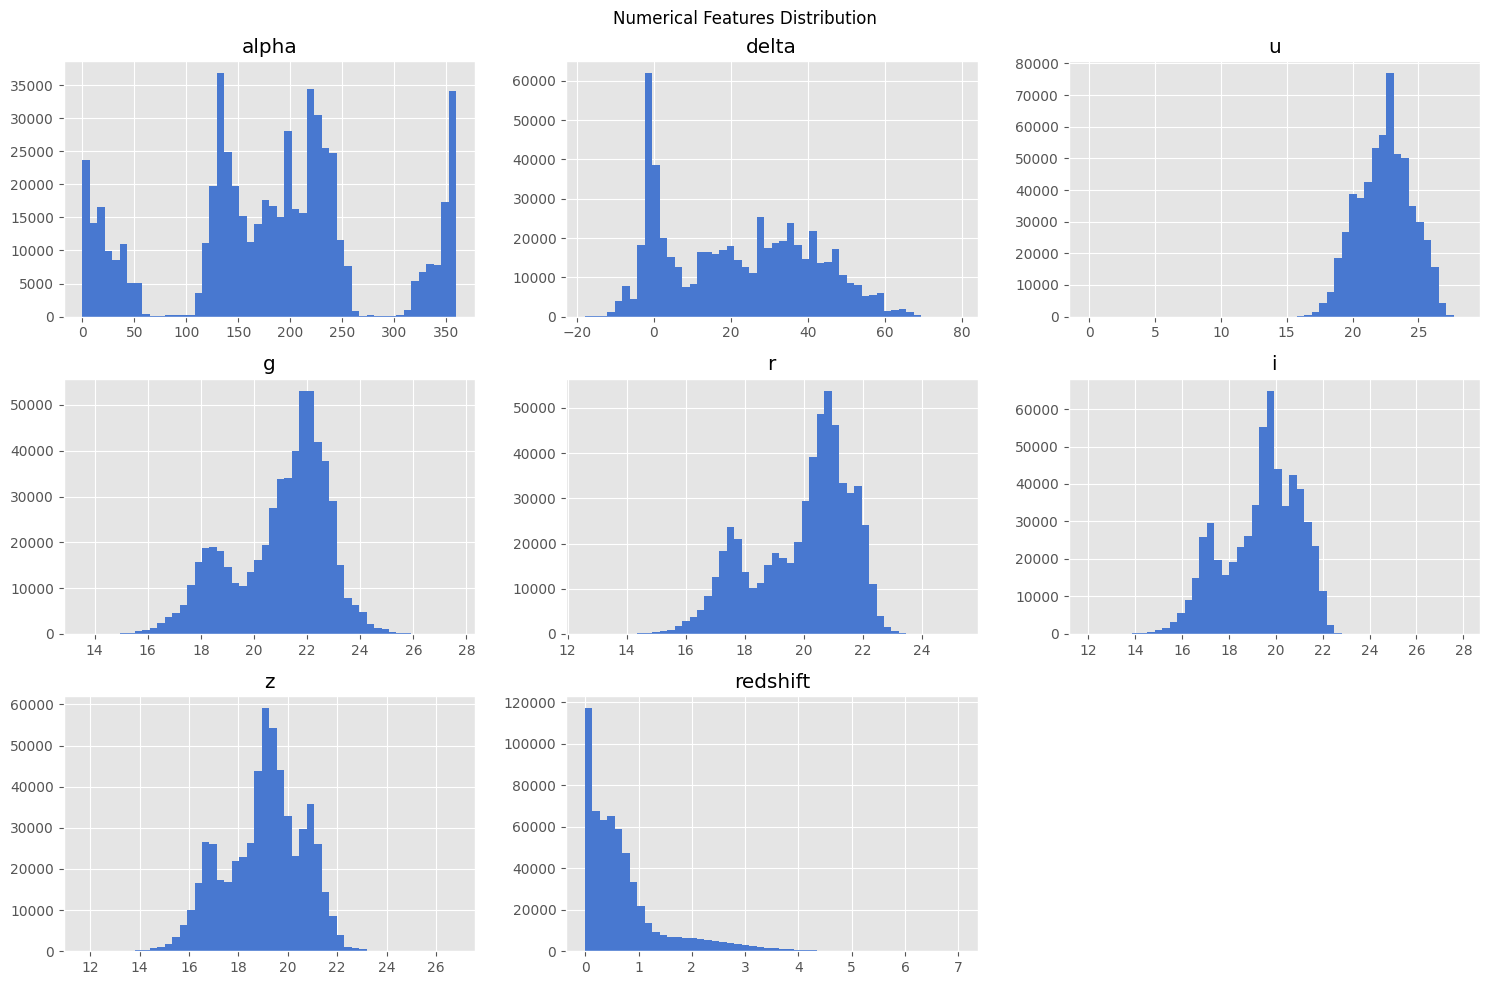

In [6]:
num_cols = ['alpha', 'delta', 'u', 'g', 'r', 'i', 'z', 'redshift']
train[num_cols].hist(bins=50, figsize=(15, 10))
plt.suptitle('Numerical Features Distribution')
plt.tight_layout()
plt.show()

## Categorical Features Distribution

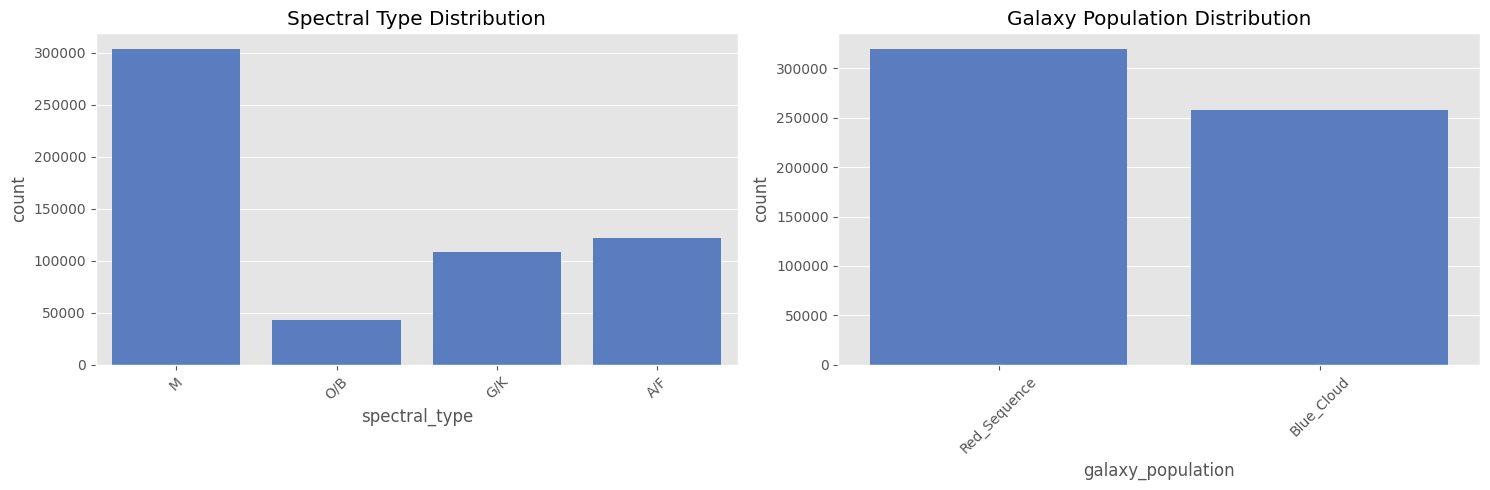

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.countplot(data=train, x='spectral_type', ax=axes[0])
axes[0].set_title('Spectral Type Distribution')
axes[0].tick_params(axis='x', rotation=45)

sns.countplot(data=train, x='galaxy_population', ax=axes[1])
axes[1].set_title('Galaxy Population Distribution')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## Correlation Analysis

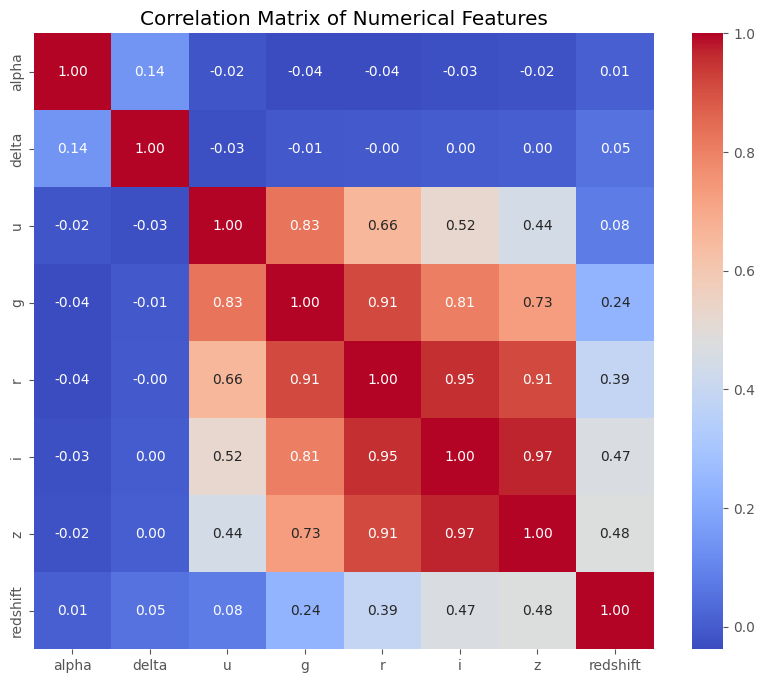

In [8]:
plt.figure(figsize=(10, 8))
corr = train[num_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

## Bivariate Analysis

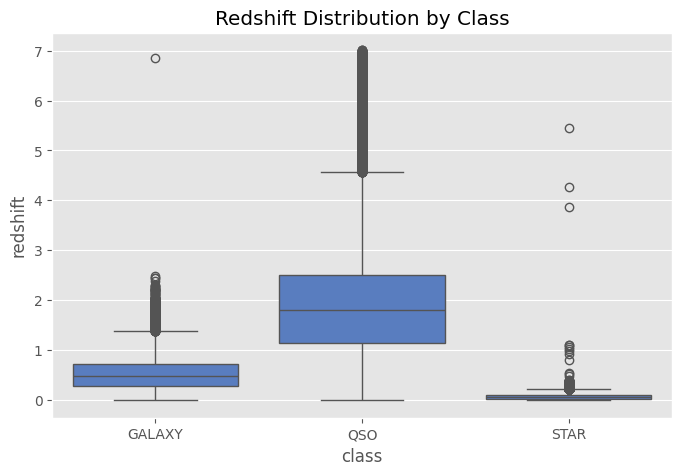

In [9]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=train, x='class', y='redshift')
plt.title('Redshift Distribution by Class')
plt.show()

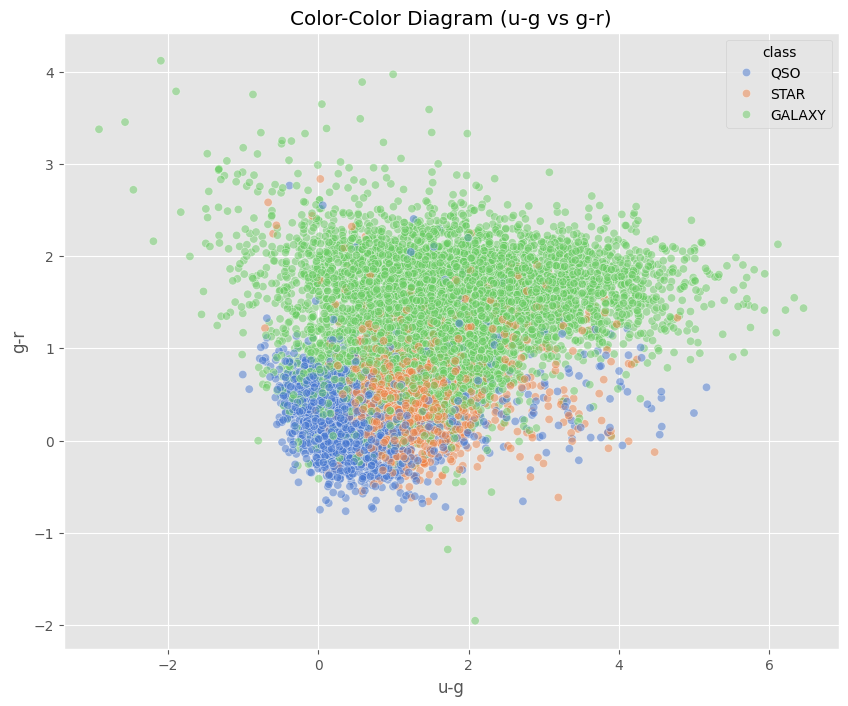

In [10]:
# Feature engineering for colors
train['u-g'] = train['u'] - train['g']
train['g-r'] = train['g'] - train['r']

plt.figure(figsize=(10, 8))
# Sample 10,000 points so the plot is not too heavy
sns.scatterplot(data=train.sample(10000, random_state=42), x='u-g', y='g-r', hue='class', alpha=0.5)
plt.title('Color-Color Diagram (u-g vs g-r)')
plt.show()